In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("exoplanets.csv")
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [3]:
df.columns

Index(['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')

#### A clean dataset with only the necessay columns only makes it easier determine KOI habitable objects and their habitability and visualize them, in other words we're removing the noise in the dataset 

In [4]:
columns_to_keep = [
    "kepoi_name",
    "kepler_name",
    "koi_disposition", #tells us if the object is confirmed to exist
    "koi_prad", #planet radii
    "koi_teq", # planet temp
    "koi_insol", #star energy received compared to earth
    "koi_period", #orbital period
    "koi_impact", #how central the transit is
    "koi_duration", #transit duration
    "koi_depth", # transit depth
    "koi_steff", # star temp
    "koi_srad" # star radii
]

clean_df = df[columns_to_keep]
clean_df

,kepoi_name,kepler_name,koi_disposition,koi_prad,koi_teq,koi_insol,koi_period,koi_impact,koi_duration,koi_depth,koi_steff,koi_srad
0,K00752.01,Kepler-227 b,CONFIRMED,2.26,793.0,93.59,9.488036,0.146,2.95750,615.8,5455.0,0.927
1,K00752.02,Kepler-227 c,CONFIRMED,2.83,443.0,9.11,54.418383,0.586,4.50700,874.8,5455.0,0.927
2,K00753.01,NaN,FALSE POSITIVE,14.60,638.0,39.30,19.899140,0.969,1.78220,10829.0,5853.0,0.868
3,K00754.01,NaN,FALSE POSITIVE,33.46,1395.0,891.96,1.736952,1.276,2.40641,8079.2,5805.0,0.791
4,K00755.01,Kepler-664 b,CONFIRMED,2.75,1406.0,926.16,2.525592,0.701,1.65450,603.3,6031.0,1.046
...,...,...,...,...,...,...,...,...,...,...,...,...
9559,K07984.01,NaN,FALSE POSITIVE,1.11,929.0,176.40,8.589871,0.765,4.80600,87.7,5638.0,1.088
9560,K07985.01,NaN,FALSE POSITIVE,29.35,2088.0,4500.53,0.527699,1.252,3.22210,1579.2,5638.0,0.903
9561,K07986.01,NaN,CANDIDATE,0.72,1608.0,1585.81,1.739849,0.043,3.11400,48.5,6119.0,1.031
9562,K07987.01,NaN,FALSE POSITIVE,1.07,2218.0,5713.41,0.681402,0.147,0.86500,103.6,6173.0,1.041


In [5]:
# # Koi_disposition tells us if the planet actually exist and if it doesnt. 
# FALSEPOSITIVE means its not a planet
# CONFIRMED means it's definitely a planet
#find the number of koi that are either candidates, confirmed, or false positives
counts = clean_df["koi_disposition"].value_counts()
counts

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

In [6]:
import matplotlib.pyplot as plt

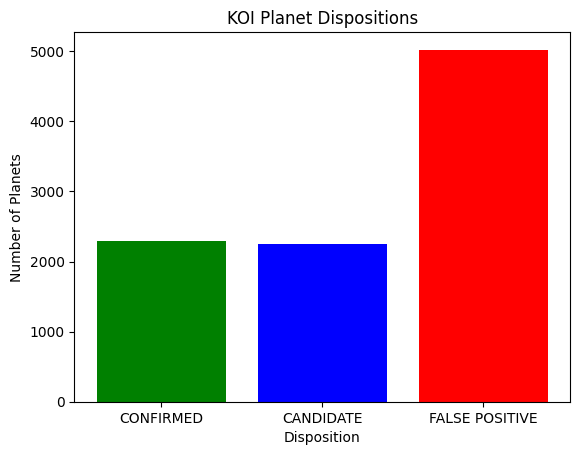

In [7]:
# order = ["CONFIRMED", "CANDIDATES", "FALSE POSITIVES"]
# counts = counts.reindex(order)
order = ['CONFIRMED','CANDIDATE','FALSE POSITIVE']
counts = counts.reindex(order)
plt.bar(counts.index, counts.values, color=['green', 'blue', 'red'])
plt.xlabel("Disposition")
plt.ylabel("Number of Planets")
plt.title("KOI Planet Dispositions")
plt.show()

In [8]:
# # We only need the confirmed planets in this dataset and optionally the candidates.
# i'm goimg to include the candidates for learning and more data analysis purposes
cc_df = clean_df.loc[clean_df["koi_disposition"].isin(["CONFIRMED", "CANDIDATE"])]
cc_df #dataframe with confirmed and candidate.

,kepoi_name,kepler_name,koi_disposition,koi_prad,koi_teq,koi_insol,koi_period,koi_impact,koi_duration,koi_depth,koi_steff,koi_srad
0,K00752.01,Kepler-227 b,CONFIRMED,2.26,793.0,93.59,9.488036,0.146,2.9575,615.8,5455.0,0.927
1,K00752.02,Kepler-227 c,CONFIRMED,2.83,443.0,9.11,54.418383,0.586,4.5070,874.8,5455.0,0.927
4,K00755.01,Kepler-664 b,CONFIRMED,2.75,1406.0,926.16,2.525592,0.701,1.6545,603.3,6031.0,1.046
5,K00756.01,Kepler-228 d,CONFIRMED,3.90,835.0,114.81,11.094321,0.538,4.5945,1517.5,6046.0,0.972
6,K00756.02,Kepler-228 c,CONFIRMED,2.77,1160.0,427.65,4.134435,0.762,3.1402,686.0,6046.0,0.972
...,...,...,...,...,...,...,...,...,...,...,...,...
9550,K07888.01,NaN,CANDIDATE,0.60,1137.0,395.05,4.736816,0.218,2.8400,35.3,6088.0,1.011
9551,K07889.01,NaN,CANDIDATE,2.44,332.0,2.86,130.235324,0.075,5.6780,750.1,5616.0,0.903
9557,K03875.01,NaN,CANDIDATE,39.46,1151.0,414.26,8.870416,1.206,1.2864,873.1,6022.0,1.514
9558,K03891.01,NaN,CANDIDATE,78.98,751.0,75.40,47.109631,1.230,5.7410,752.2,5258.0,2.780


In [9]:
#To narrow down habitable planets we'll compare the koi with earth conditions according to the available data.
# koi_prad — 1.0 Earth radii (by definition)
# koi_teq — ~255 K (Earth's equilibrium temperature)
# koi_insol — 1.0 Earth flux (by definition)
# koi_steff — ~5778 K (our Sun)
# koi_srad — 1.0 Solar radii
# koi_period — 365.25 days

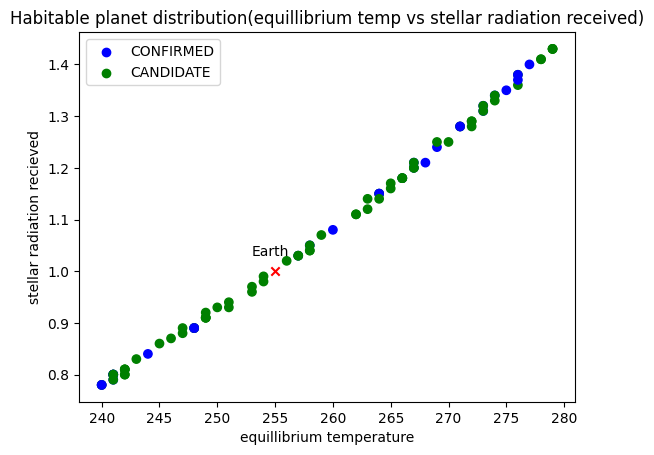

In [10]:
# what we need is the dataset to have planets whose given propertie closely resemble earth
#we create a mask, and a data frame for a scatter plot named 'sc_df'
mask =(
    (cc_df["koi_teq"] >= 240) & (cc_df["koi_teq"] <= 280) & 
    (cc_df["koi_insol"] >= 0.25) & (cc_df["koi_insol"] <= 1.5)
)
# I use equillibrium temp and stellar energy received (koi_insol) to plot the scatter plot
sc_df = cc_df[mask]
x = sc_df["koi_teq"]
y = sc_df["koi_insol"]
plt.xlabel("equillibrium temperature")
plt.ylabel("stellar radiation recieved")
plt.title("Habitable planet distribution(equillibrium temp vs stellar radiation received)")

categories = sc_df['koi_disposition'].unique()
colors = ['blue', 'green'] 
color_map = dict(zip(categories, colors))


plt.scatter(
    x,
    y,
    c = sc_df["koi_disposition"].map(color_map),
)

#legend
for cat, col in color_map.items():
    plt.scatter([], [], c=col, label=cat)
plt.legend()

# To see where these compare next to earth i plot an earth ref point in the plot as an x mark.
ref_x = 255
ref_y = 1
plt.scatter (ref_x, ref_y, color = 'red', marker = 'x')
plt.text(ref_x - 2, ref_y + 0.03, "Earth", color='black')
plt.show()

#### The relationship between stellar radiation received and equillibrium temperature is linear , hence it doesnt really help us get a good spread, since one is used to derive the other, equillibrium temp is derived from stellar radiation received.

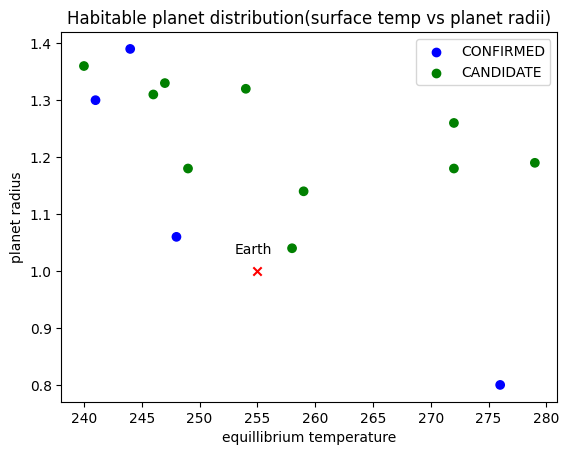

In [11]:
# I apply the same method as above but instead i use eq.temp and planet radii.
# size of the planet determines where it can hold an atmosphere or not with its gravity.
mask =(
    (cc_df["koi_teq"] >= 240) & (cc_df["koi_teq"] <= 280) & 
    (cc_df["koi_prad"] >= 0.5) & (cc_df["koi_prad"] <= 1.5)
)

sc_df = cc_df[mask].copy()
x = sc_df["koi_teq"]
y = sc_df["koi_prad"]
plt.xlabel("equillibrium temperature")
plt.ylabel("planet radius")
plt.title("Habitable planet distribution(surface temp vs planet radii)")

categories = sc_df['koi_disposition'].unique()
colors = ['blue', 'green'] 
color_map = dict(zip(categories, colors))


plt.scatter(
    x,
    y,
    c = sc_df["koi_disposition"].map(color_map),
)

#legend
for cat, col in color_map.items():
    plt.scatter([], [], c=col, label=cat)
plt.legend()

# To see where these compare next to earth i plot an earth ref point in the plot as an x mark.
ref_x = 255
ref_y = 1
plt.scatter (ref_x, ref_y, color = 'red', marker = 'x')
plt.text(ref_x - 2, ref_y + 0.03, "Earth", color='black')
plt.show()

In [12]:
# We get to see how closely do these planets resemble earth by including the rest of their properties
#from the properties we'll calculate a score using the gaussian method 
#the method shows us how much do these planets deviate from the planet earth
# the gaussian formula : score = exp( -( (value - earth_value)² / (2 × σ²) ) )

In [13]:
earth = {
    'koi_prad': 1.0,
    'koi_teq': 255,
    'koi_insol': 1.0,
    'koi_steff': 5778,
    'koi_srad': 1.0,
    'koi_period': 365.25
}

sigmas = {
    'koi_prad': 0.5,
    'koi_teq': 25,
    'koi_insol': 0.35,
    'koi_steff': 1000,
    'koi_srad': 0.5,
    'koi_period': 100
}

In [14]:
#make the gaussian formula as a function
def gaussian(value, earth_val, sigma):
    return np.exp(-((value - earth_val)**2) / (2 * sigma**2))

sc_df['score_prad'] = gaussian(sc_df['koi_prad'], 1.0, 0.5)
sc_df['score_teq'] = gaussian(sc_df['koi_teq'], 255, 25)
sc_df['score_insol'] = gaussian(sc_df['koi_insol'], 1.0, 0.35)
sc_df['score_steff'] = gaussian(sc_df['koi_steff'], 5778, 1000)
sc_df['score_srad'] = gaussian(sc_df['koi_srad'], 1.0, 0.5)
sc_df['score_period'] = gaussian(sc_df['koi_period'], 365.25, 100)

sc_df['habitability_score'] = sc_df[['score_prad', 'score_teq', 'score_insol', 
                                'score_steff', 'score_srad']].mean(axis=1)
sc_df.count()

kepoi_name            14
kepler_name            4
koi_disposition       14
koi_prad              14
koi_teq               14
koi_insol             14
koi_period            14
koi_impact            14
koi_duration          14
koi_depth             14
koi_steff             14
koi_srad              14
score_prad            14
score_teq             14
score_insol           14
score_steff           14
score_srad            14
score_period          14
habitability_score    14
dtype: int64

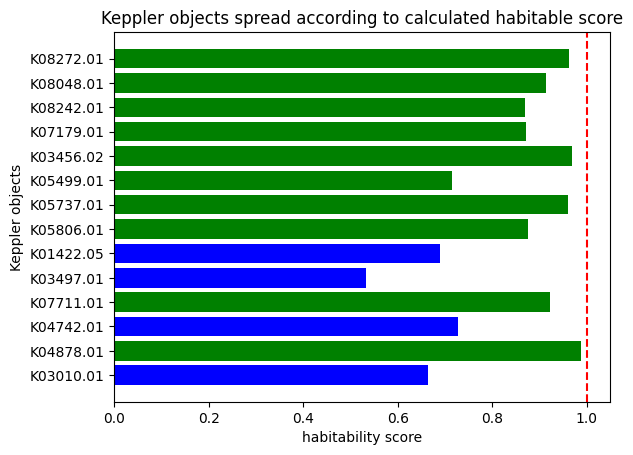

In [15]:
# we plot a verticle bar graph to show the deviation of these planets from earth

keppler_objects = sc_df['kepoi_name']
values = sc_df['habitability_score']

categories = sc_df['koi_disposition'].unique()
colors = ['blue', 'green'] 
color_map = dict(zip(categories, colors))
bar_colors = sc_df['koi_disposition'].map(color_map)

#add a red line earth referencer
plt.axvline(x=1.0, color='red', linestyle='--', label='Earth')

plt.barh(keppler_objects, values, color = bar_colors)
plt.xlabel('habitability score')
plt.ylabel('Keppler objects')
plt.title('Keppler objects spread according to calculated habitable score')
plt.show()

In [17]:
# To see which characteristics make the top habitable KIO habitable i'll plot a spider chart
#but since we have candidates and confirmed planets , ill plot two spider charts of both 
#but first we need to get the top values in their own dataframe.
spider_df_conf = sc_df[sc_df['koi_disposition'] == 'CONFIRMED']
spider_df_conf = spider_df_conf.nlargest(3, 'habitability_score') #dataframe with top 3 habitable candidates according to habitability score
spider_df_conf

,kepoi_name,kepler_name,koi_disposition,koi_prad,koi_teq,koi_insol,koi_period,koi_impact,koi_duration,koi_depth,koi_steff,koi_srad,score_prad,score_teq,score_insol,score_steff,score_srad,score_period,habitability_score
4648,K04742.01,Kepler-442 b,CONFIRMED,1.30,241.0,0.79,112.303136,0.248,5.869,502.1,4401.0,0.595,0.835270,0.854875,0.835270,0.387490,0.720327,0.040799,0.726647
5830,K01422.05,Kepler-296 e,CONFIRMED,1.06,248.0,0.89,34.142051,0.105,2.945,788.0,3526.0,0.383,0.992826,0.961558,0.951812,0.079202,0.467022,0.004163,0.690484
2616,K03010.01,Kepler-1410 b,CONFIRMED,1.39,244.0,0.84,60.866097,0.004,4.397,714.3,3808.0,0.522,0.737713,0.907738,0.900784,0.143639,0.633201,0.009731,0.664615


In [16]:
# To see which characteristics make the top habitable KIO habitable i'll plot a spider chart
#but since we have candidates and confirmed planets , ill plot two spider charts of both 
#but first we need to get the top values in their own dataframe.
spider_df_cand = sc_df[sc_df['koi_disposition'] == 'CANDIDATE']
spider_df_cand = spider_df_cand.nlargest(3, 'habitability_score') #dataframe with top 3 habitable candidates according to habitability score
spider_df_cand

,kepoi_name,kepler_name,koi_disposition,koi_prad,koi_teq,koi_insol,koi_period,koi_impact,koi_duration,koi_depth,koi_steff,koi_srad,score_prad,score_teq,score_insol,score_steff,score_srad,score_period,habitability_score
4615,K04878.01,NaN,CANDIDATE,1.04,258.0,1.04,449.01499,0.2182,12.580,94.2,6031.0,1.068,0.996805,0.992826,0.993491,0.968502,0.990795,0.704104,0.988484
6907,K03456.02,NaN,CANDIDATE,1.18,249.0,0.91,486.12702,0.3621,9.495,120.6,6008.0,1.062,0.937255,0.971611,0.967479,0.973897,0.992341,0.481638,0.968517
9330,K08272.01,NaN,CANDIDATE,1.14,259.0,1.07,432.42787,0.7160,19.630,110.3,6263.0,1.009,0.961558,0.987282,0.980199,0.889040,0.999838,0.798003,0.963583


#### To conclude , among the top exoplanets their most similar and defining quality that bring them close to earth's habitability is their equillibrium temperature, stellar energy received and planetary radii which hints to having a similar size to our planet. Our star is much larger than theirs which would explain why we have a larger revolution period around our star( the sun ) however despite it's size the sun has lower surface temperature compared to theirs.

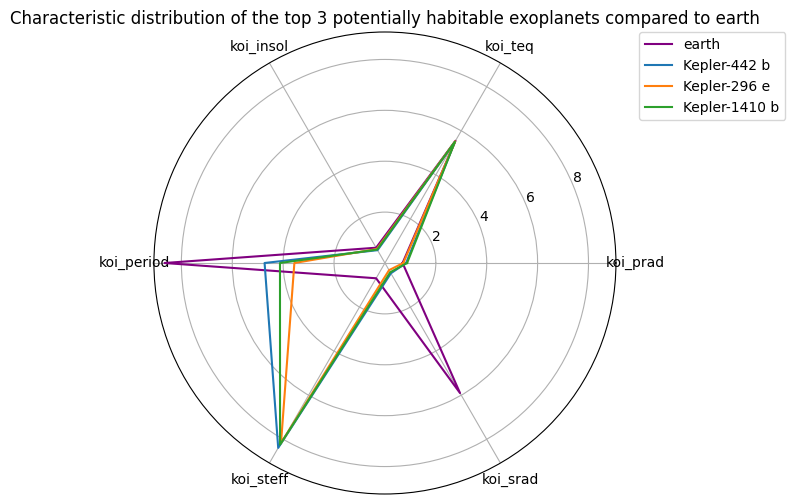

In [87]:
#Get the columns needed for the labeling and plotting of the spider chart
label_columns = spider_df_conf.columns[spider_df_conf.columns.isin(['koi_prad','koi_teq','koi_insol','koi_steff','koi_srad','koi_period'])]

#scale the values so they can be well balanced since we have extreme values in our dataset(0.13 vs 4000)
spider_scaled = spider_df_conf[label_columns].apply(lambda x: np.log1p(x))

#plot the angles that will represent your values in the plot
angles = np.linspace(start = 0, stop = 2*np.pi, num  = len(label_columns) + 1)# we add 1 to compensate for the first value that will be used to close the loop in the chart and will appear twice)
plt.figure(figsize =(6,6))
ax = plt.subplot(polar = True)

#make the reference point to compare, in this case its earth
earth = [1.0, 255, 1.0, 5778, 1.0, 365.25, 1.0]

#turn into a series and then scale its values too to balance them out for better visuals
earth_series = pd.Series(earth)
spider_scaled_earth = earth_series.apply(lambda x: np.log1p(x))
#plot it on the plot with a color that stands out
ax.plot(angles, spider_scaled_earth, label = "earth", color = 'purple')
# plot the values in teh dataset , by looping or other appropiat method
for i in range(len(spider_scaled)):
    values = spider_scaled.iloc[i][label_columns].values
    values = np.concatenate([values, [values[0]]])
    name = spider_df_conf.iloc[i]['kepler_name']
    ax.plot(angles,values, label = name)
# label the plot
ax.set_xticks(angles[:-1])
ax.set_xticklabels(label_columns)
#plot the graph
ax.legend(
    loc='upper left',           
    bbox_to_anchor=(1.05, 1),  
    borderaxespad=0.,           
    fontsize=10                
)
plt.title("Characteristic distribution of the top 3 potentially habitable exoplanets compared to earth")
plt.show()

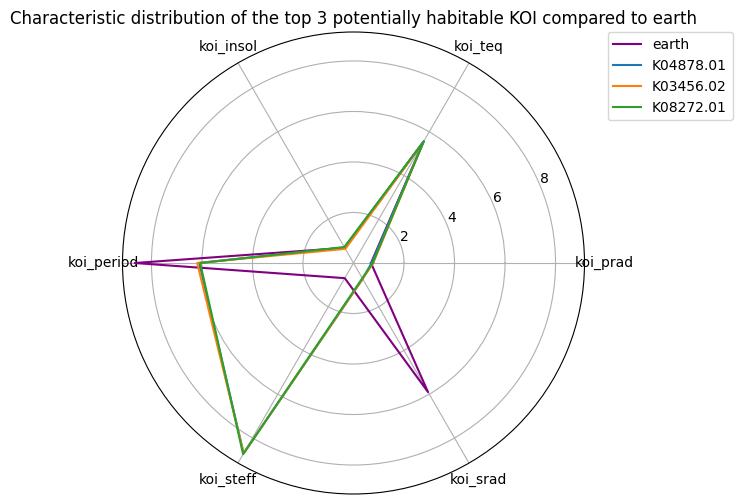

In [86]:
#Get the columns needed for the labeling and plotting of the spider chart
label_columns = spider_df_cand.columns[spider_df_conf.columns.isin(['koi_prad','koi_teq','koi_insol','koi_steff','koi_srad','koi_period'])]

#scale the values so they can be well balanced since we have extreme values in our dataset(0.13 vs 4000)
spider_scaled = spider_df_cand[label_columns].apply(lambda x: np.log1p(x))

#plot the angles that will represent your values in the plot
angles = np.linspace(start = 0, stop = 2*np.pi, num  = len(label_columns) + 1)# we add 1 to compensate for the first value that will be used to close the loop in the chart and will appear twice)
plt.figure(figsize =(6,6))
ax = plt.subplot(polar = True)

#make the reference point to compare, in this case its earth
earth = [1.0, 255, 1.0, 5778, 1.0, 365.25, 1.0]

#turn into a series and then scale its values too to balance them out for better visuals
earth_series = pd.Series(earth)
spider_scaled_earth = earth_series.apply(lambda x: np.log1p(x))
#plot it on the plot with a color that stands out
ax.plot(angles, spider_scaled_earth, label = "earth", color = 'purple')
# plot the values in teh dataset , by looping or other appropiat method
for i in range(len(spider_scaled)):
    values = spider_scaled.iloc[i][label_columns].values
    values = np.concatenate([values, [values[0]]])
    name = spider_df_cand.iloc[i]['kepoi_name']
    ax.plot(angles,values, label = name)
# label the plot
ax.set_xticks(angles[:-1])
ax.set_xticklabels(label_columns)
#plot the graph
ax.legend(
    loc='upper left',           
    bbox_to_anchor=(1.05, 1),  
    borderaxespad=0.,           
    fontsize=10                
)
plt.title("Characteristic distribution of the top 3 potentially habitable KOI compared to earth")
plt.show()

#### To conclude , among the top unconfirmed keppler objects their most similar and defining quality that bring them close to earth's habitability is their equillibrium temperature, period(rotation around their star) which is much closer than the confirmed exoplanets, stellar energy received and planetary radii which hints to having a similar size to our planet. Our star is much larger than theirs but has lower surface temperature compared to theirs.